# Bias correction Tasmin 

<font size ='4'>Tasmin:- Daily minimum temperature </font>

<font size ='4'>DTR: Diurnal temperature range</font>

In [1]:
from glob import glob
from pathlib import Path
from os.path import basename
import zipfile
import matplotlib.pyplot as plt

#Librairies for working with multi-dimensional arrays
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr #Opening netcdf files as datasets and dataArrays
import pandas as pd
import os

In [ ]:
#Libraries for working with climate data
#Projecting the files
import cartopy.crs as ccrs  # projection
import rioxarray
import rasterio

import xesmf as xe    #For regridding climate data

In [3]:
# Cliping netcdf file

from shapely.geometry import mapping
import geopandas as gpd  #for reading the shapefile
import regionmask  #For masking dataset


In [4]:
#Xclim module
import xclim as xc
from xclim import sdba

from xclim import ensembles

In [5]:
#Let import the models needed
from cmethods import CMethods as cm

#Libaray  suite of correlation-based and distance-based deterministic metrics:
import xskillscore as xs

In [6]:
#Finland Shape file
shapefile = r"C:\Christine\DEM\FIN_adm\FIN_adm0.shp"
shp_fin= gpd.read_file(shapefile)  # reading shapefile with geopandas


## A. Defining Functions

In [ ]:
def input_prep(cm):
    #Normalize the dates
    cm['time']= cm.indexes['time'].normalize()
    return cm

def calendar(ds):
    ds = xc.core.calendar.convert_calendar(ds,'noleap')
    return ds

def change_calendar(cm): #changes dates from object to datetime
    datetimeindex = cm.indexes['time'].to_datetimeindex()
    cm['time'] = datetimeindex
    return cm

    
def units_conv(cm):    
    #Changing units from Kelvins to degrees celcuis
    cm['tasmin'] = cm['tasmin']-273.15
    cm['tasmin'].attrs['units'] = 'degC' #'degree celcius'
    cm['lat'].attrs['units'] ='degrees north '
    cm['lon'].attrs['units'] ='degrees east'
    
    return cm
    

#Regridding

def coarse_fine(coarse_nc, fine_nc):
    regridder= xe.Regridder(coarse_nc, fine_nc, 'bilinear',unmapped_to_nan=True)
    cm_ds=regridder(coarse_nc, skipna=True, na_thres=.01, keep_attrs= True)
    return cm_ds

def fine_coarse1(fine_nc, coarse_nc):
    #regridder= xe.Regridder(fine_nc, coarse_nc, 'bilinear',extrap_method= 'nearest_s2d',unmapped_to_nan=True)
    
    regridder= xe.Regridder(fine_nc, coarse_nc, 'conservative',unmapped_to_nan=True)#
    cm1= regridder(fine_nc, skipna=True, na_thres=.01, keep_attrs= True)
    return cm1

def clip_fin(cm, shp):
    cm = cm.rename({'lat':'y', 'lon':'x'}) # Specifiying the coordinate system
    cm.rio.write_crs("EPSG:4326",inplace= True)
    
    cm_fin= cm.rio.clip(shp.geometry.apply(mapping), shp.crs, all_touched= True, drop= True)
    #cm_fin= cm.rio.clip(shp.geometry.apply(mapping), shp.crs)
    
    cm_fin= cm_fin.rename({'y':'lat', 'x':'lon'})
    return cm_fin



### Detrending and bias correction

In [7]:

#Tas and Detrending
def tas_detrended_qdm(obs, simh, simp):
    obs= xc.core.calendar.convert_calendar(obs, "noleap")
    simh= xc.core.calendar.convert_calendar(simh, "noleap")
    simp= xc.core.calendar.convert_calendar(simp, "noleap")
    
    
    ref= obs['DTR']
    hist= simh['DTR']
    sim= simp['DTR']
    
    #Deleting experiment ccordinate from the dataset
    hist= hist.reset_coords(names="experiment", drop=True)
    sim= sim.reset_coords(names="experiment", drop=True)
    
    doy_win31 = sdba.Grouper("time.dayofyear", window=15)
    Sca = sdba.Scaling.train(ref, hist, group=doy_win31, kind="+")
    sim_scl = Sca.adjust(sim)

    detrender = sdba.detrending.PolyDetrend(degree=1, group="time.dayofyear", kind="+")
    sim_fit = detrender.fit(sim_scl)
    sim_detrended = sim_fit.detrend(sim_scl)

    ref_n, _ = sdba.processing.normalize(ref, group=doy_win31, kind="+")
    hist_n, _ = sdba.processing.normalize(hist, group=doy_win31, kind="+")

    QM = sdba.QuantileDeltaMapping.train(
        ref_n, hist_n, nquantiles=20, group="time.month", kind="+"
    )
    scen_detrended = QM.adjust(sim_detrended, extrapolation="constant", interp="linear")
    scen = sim_fit.retrend(scen_detrended)
    
    cm_bc=simp.copy()
    cm_bc['DTR'] = scen
    return cm_bc    
    

### Statistical Metrics

In [ ]:
#Assessing performance of model against observed data
def coeff_determ(ref, bc):
    #Using Coeffecient of determination
    R2= xs.r2(ref.tasmin, bc.tasmin, dim='time', skipna=True, keep_attrs=True)

    #converting to array
    R2_arr= np.array(R2)
    r2= np.nanmean(R2_arr)
    return r2

   
def mean_absolute_error(ref, bc):
    MAE= xs.mae(ref.tasmin, bc.tasmin, dim='time', skipna=True, keep_attrs=True)
    #converting to array
    MAE_arr= np.array(MAE)
    mae= np.nanmean(MAE_arr)
    return mae 

def pearson_correlation(ref, bc):
    R= xs.pearson_r(ref.tasmin, bc.tasmin, dim='time', skipna=True, keep_attrs=True)
    #converting to array
    r_arr= np.array(R)
    r= np.nanmean(r_arr)
    return r


def standard_deviation(ref):
    st_dev= ref.std(skipna=True)
    #converting to array
    std_arr= np.nanmean(st_dev.tasmin)
    
    return std_arr 

def root_mean_square_error(ref, bc):
    RMSE= xs.rmse(ref.tasmin, bc.tasmin, dim='time', skipna=True, keep_attrs=True)
    #converting to array
    rmse_arr= np.array(RMSE)
    rmse= np.nanmean(rmse_arr)
    return rmse

In [8]:
def ens_period(cm, start, end):
    cm_period= cm.tasmin[1:5].sel(time= slice(start, end))
    return cm_period

def spatial_agg(cm):
    weights = np.cos(np.deg2rad(cm.lat))
    weights.name= 'weights'
    cm_weighted= cm.weighted(weights)
    cm_agg = cm_weighted.mean(['lat','lon'])
    
    return cm_agg

def groupby_season(cm):
    
    cm_season_mean= cm.groupby('time.season').mean('time',skipna=False).sortby(xr.DataArray(['DJF','MAM','JJA', 'SON'],dims=['season']))
    cm_season_mean.attrs['units'] ='degC'
    return cm_season_mean


def groupby_day(cm):
    cm_day= cm.groupby('time.dayofyear').mean('time',skipna=False)
    cm_day.attrs['units'] ='degC'
    return cm_day


def groupby_month(cm):
   
    cm_month_mean= cm.groupby('time.month').mean('time',skipna=False)
    cm_month_mean.attrs['units'] ='degC'
    return cm_month_mean

def groupby_year(cm):
    cm_yr= cm.groupby('time.year').mean('time',skipna=False)
    cm_yr.attrs['units'] ='degC'
    return cm_yr

def anomly(cm, cm_his):
    cm_change=  (cm-cm_his)
    cm_change.attrs['units'] ='degC'

    return cm_change 

def anomly_day(cm, cm_his):
    cm_change=  (cm-cm_his)
    cm_change.attrs['units'] ='degC'

    return cm_change 

### Dirunal Temperature Range 
<font size ='3'> DTR= Tmax-Tmin</font>

In [9]:
def DTR(ds_max, ds_min):
    dr_dtr= ds_max.tasmax-ds_min.tasmin
    
    dr_dtr.attrs['units'] ='degC'
    dr_dtr.attrs['long_name'] ='Daily temperature range'
    
    
    ds_dtr= dr_dtr.to_dataset(name='DTR')
    
    
    return ds_dtr

In [ ]:
#reading observed gridded data for Finland
cm_obs_max = xr.open_dataset(r"C:\Christine\Hydrology\Gridded data Observed Finland\Obs_Fin\tasmax_latlon.nc")

cm_obs_max= cm_obs_max.rename({'tmax':'tasmax'})

cm_obs_max= cm_obs_max.reset_coords(names="spatial_ref", drop=True)


#Daily minimum temperature
cm_obs_min = xr.open_dataset(r"C:\Christine\Hydrology\Gridded data Observed Finland\Obs_Fin\Tmin_latlon.nc")

cm_obs_min= cm_obs_min.rename({'tmin':'tasmin'})
cm_obs_min= cm_obs_min.reset_coords(names="spatial_ref", drop=True)


In [11]:
cm_obs_fin_min= clip_fin(cm_obs_min, shp_fin)

#### Computing DTR

In [ ]:
cm_obs_dtr= DTR(cm_obs_max, cm_obs_min)

#Slicing to match the historical model data
cm_obs_DTR= cm_obs_dtr.sel(time=slice(None, '2014-12-31'))

cm_obs_DTR= cm_obs_DTR.sel(time=~((cm_obs_DTR.time.dt.month == 2) & (cm_obs_DTR.time.dt.day == 29)))


#Clipping to the shapefile of Finland
cm_obs_fin = clip_fin(cm_obs_DTR, shp_fin)

In [14]:
#Regridder to 1 x 1 degree
ds_out1 = xr.Dataset(
    {
        "lat": (["lat"], np.arange(cm_obs_fin.lat[-1], cm_obs_fin.lat[0]+1, 1), {"units": "degrees_north"}),
        "lon": (["lon"], np.arange(cm_obs_fin.lon[0],cm_obs_fin.lon[-1]+1, 1), {"units": "degrees_east"}),
    }
)


In [ ]:
plt.figure()
ax= plt.axes()
cm_obs_fin['DTR'][215].plot.pcolormesh(ax=ax, cmap='Blues')
shp_fin.plot(ax= ax,alpha= 0.5, facecolor='none')
plt.show()

## Regridding to 1 x 1 degree

In [ ]:
#Directory to read historical data

DATADIR= r"D:\GCM\MPI-ESM1-2-LR\Historical\tasmin*.nc"
path= glob(f'{DATADIR}')

In [15]:
#Directory to read model data
DATADIR2= r"D:\GCM\MPI-ESM1-2-LR\SSP*\tasmin*.nc"
path2= glob(f'{DATADIR2}')

In [17]:
#Directory to store the data

DATADIR3= r"D:\GCM\MPI-ESM1-2-LR\CMIP6 data/"

In [ ]:
for file in path:
    cm_hist= xr.open_dataset(file)
    #Getting attibutes
    exp= cm_hist.attrs['experiment_id']
    mod = cm_hist.attrs['source_id']
    var= cm_hist.attrs['variable_id']
    
    #changing dates from cft date time to datetime    
    #datetimeindex = cm_hist.indexes['time'].to_datetimeindex()
    #cm_hist['time']=datetimeindex

    #Changing the date format ( can be skipped if not needed)
    cm_hist= cm_hist.sel(time=~((cm_hist.time.dt.month == 2) & (cm_hist.time.dt.day == 29)))
    cm_hist= input_prep(cm_hist)
    
    #Dropping variables
    cm_hist= cm_hist.drop_vars(["time_bnds",'lat_bnds','lon_bnds'])
    #cm_hist= cm_hist.drop_vars(["time_bounds"])

    #converting units
    cm_hist= units_conv(cm_hist)

    #Regridding data to 1x1 grid
    cm_hist_ds= coarse_fine(cm_hist, ds_out1)
    
    #Clipping to finland
    #cm_hist1_fin = clip_fin(cm_hist1, shp_fin)
    #bias correction of historical data
    
    cm_hist_ds.to_netcdf(f'{DATADIR3}{var}_{mod}_{exp}.nc')
    print('worked on historical file')

for file in path2:

    cm_raw= xr.open_dataset(file)
    
    try:

        #Getting attibutes
        exp= cm_raw.attrs['experiment_id']
        mod = cm_raw.attrs['source_id']
        var= cm_raw.attrs['variable_id']
        
        #changing dates from cft date time to datetime    
        #datetimeindex = cm_raw.indexes['time'].to_datetimeindex()
        #cm_raw['time']=datetimeindex
        
        #Changing the date format ( can be skipped if not needed)
        
        cm_raw= cm_raw.sel(time=~((cm_raw.time.dt.month == 2) & (cm_raw.time.dt.day == 29)))
              
        cm_raw= input_prep(cm_raw)
        
        
        #Dropping variables
        cm_raw= cm_raw.drop_vars(["time_bnds",'lat_bnds','lon_bnds'])
        #cm_raw= cm_raw.drop_vars(["time_bounds"])

        #converting units
        cm_raw= units_conv(cm_raw)

        #Regridding data to 1x1 grid
        
        cm_raw_ds= coarse_fine(cm_raw, ds_out1)
        
        #Clipping to finland
        #cm_raw1_fin = clip_fin(cm_raw1, shp_fin)

        #bias correction
        #cm_bc= quantile_delta_mapping(cm_obs1, cm_hist1, cm_raw1)
        
        
        #Exporting file
        cm_raw_ds.to_netcdf(f'{DATADIR3}{var}_{mod}_{exp}.nc')
        print(f'{var}_{mod}_{exp} has been exported')

      
    except Exception as err:
        print(err)

### Raw GCm Model performance against Observed data

In [21]:
cm_obs_min2014 = cm_obs_fin_min.sel(time=slice(None,'2014-12-31'))

In [23]:
cm_obs2014m= cm_obs_min2014.resample(time='M').mean(dim='time', skipna=False)

In [25]:
sd_obsm= cm_obs2014m.std(skipna= True)
sdm= np.nanmean(sd_obsm.tasmin)
print(sdm)

9.531015396118164


In [19]:
DATADIR7= r"D:\GCM\**\CMIP6 data\tasmin_*hist*.nc"
path7= glob(f'{DATADIR7}')

In [ ]:
for file in path7:

    cm_bc= xr.open_dataset(file)
    
    try:

        #Getting attibutes
        exp= cm_bc.attrs['experiment_id']
        mod = cm_bc.attrs['source_id']        
               
        cm_bc= input_prep(cm_bc)

        
        #from coarse to fine grid
        cm_bc_ds= coarse_fine(cm_bc, cm_obs_min)

        #Clipping to finland
        cm_bc_fin = clip_fin(cm_bc_ds, shp_fin)
        cm_bc_fin_m = cm_bc_fin.resample(time='M').mean(dim='time', skipna=False)

        #Evalution of methods
         #Person Correlation
        print(f'The coefficient of correlation before  bias correcction of model {mod} is {pearson_correlation(cm_obs2014m, cm_bc_fin_m)}')
               
     
        #Absolute mean error.
        
        print(f'The mean Absolute error before  bias correcction of model {mod} is {mean_absolute_error(cm_obs2014m, cm_bc_fin_m)}')
        
        # Standard deviation
        print(f'The Standard devaiation before bias correcction of model {mod} is {standard_deviation(cm_bc_fin_m)}')
        
        print(f'The root_mean_square_error before bias correcction of model {mod} is {root_mean_square_error(cm_obs2014m, cm_bc_fin_m)}')

        
       
    except Exception as err:
        print(err)

##  GCMs Ensemble 

In [18]:

DATADIR5= r"D:\GCM\**\CMIP6 data\tasmin_*.nc"
path5= glob(f'{DATADIR5}')

In [13]:

DATADIR6= r"D:\Ensemble_Finland\Finland\Tasmin/"
path6= glob(f'{DATADIR6}*.nc')


In [14]:
def ensemble(ds):
    
    exp= ds.attrs['experiment_id']
    mod= ds.attrs['source_id']
    da= ds['tasmin']
    
    da= da.assign_coords(model= mod)
    da= da.expand_dims('model')
    
    da= da.assign_coords(experiment= exp)
    da= da.expand_dims('experiment')
    
    print(f'{exp}_{mod} has been worked on')
    
    da.to_netcdf(path=f'{DATADIR6}cmip6_tasmin_{exp}_{mod}.nc')
    
    

In [ ]:
for file in path5:
    ds= xr.open_dataset(file)
    ds= input_prep(ds)
    try:
        ensemble(ds)
    except Exception as err:
        print(err)
        

In [15]:
#combining all datasets into one
#data_ds= xr.open_mfdataset(f'{DATADIR6}cmip6*.nc')
data_ds= xr.open_mfdataset(f'{DATADIR6}cmip6*.nc',coords='minimal') #you try this if all files dont have the same coordinates

In [17]:
#Converting Dask Array to into memory
data_ds.load()

<xarray.Dataset>
Dimensions:     (time: 44165, lat: 12, lon: 12, model: 17, experiment: 5)
Coordinates:
  * time        (time) datetime64[ns] 1980-01-01 1980-01-02 ... 2100-12-31
  * lat         (lat) float64 59.69 60.69 61.69 62.69 ... 68.69 69.69 70.69
  * lon         (lon) float64 20.55 21.55 22.55 23.55 ... 29.55 30.55 31.55
  * model       (model) object 'ACCESS-CM2' 'AWI-CM-1-1-MR' ... 'NorESM2-MM'
  * experiment  (experiment) object 'historical' 'ssp126' ... 'ssp370' 'ssp585'
    height      float64 2.0
Data variables:
    tasmin      (experiment, model, time, lat, lon) float64 -7.067 ... -1.414

In [ ]:
#removing duplicates
#data_ds = data_ds.sel(time=~data_ds.get_index("time").duplicated())
#data_ds

# Getting ensemble mean / percentiles

In [18]:
#Finally, we create an Xarray DataArray object for the near-surface air temperature variable, ‘tas’:
data = data_ds['tasmin']


#Computing percentiles for the models
#data_90= data.quantile(0.95, dim='model',skipna=True)

data_50= data.quantile(0.5, dim='model',skipna=True)

#data_10= data.quantile(0.05, dim='model', skipna=True)

In [ ]:
#to dataframe
#ds_90 = data_90.to_dataset(name= 'tasmin_95')
ds_50 = data_50.to_dataset(name= 'tasmin_50')
#ds_10 = data_10.to_dataset(name= 'tasmin_05')

In [22]:
ds_50.to_netcdf(r"D:\Ensemble_Finland\cmip6_model_ens_tasmin2.nc")

### Reading ensemble Tmin and Tmax

In [ ]:
#Tmin
cm_min=xr.open_dataset("D:\Ensemble_Finland\cmip6_model_ens_tasmin2.nc")
cm_min= cm_min.rename({'tasmin_50':'tasmin'})

#Tmax
cm_max= xr.open_dataset(r"D:\Ensemble_Finland\cmip6_model_ens_tasmax2.nc")


#Gettig diurnal temperature range of ensemble
DTR_cm= DTR(cm_max, cm_min)

In [ ]:
#Plotting
plt.figure()
ax= plt.axes()
cm_max.tasmax[0,10100].plot.pcolormesh(ax=ax)
shp_fin.plot(ax= ax,alpha= 0.5, facecolor='none')
plt.show()

# Creating an yearly ensemble plot

In [184]:
cmip6_fin= clip_fin(data, shp_fin)

In [223]:
def groupby_year2(cm):
    cm_yr= cm.groupby('time.year').mean('time',skipna=True)
    cm_yr.attrs['units'] ='degC'
    return cm_yr

In [224]:
#Grouping by year
cmip6_ens_yr= groupby_year2(cmip6_fin)
cmip6_ens_agg = spatial_agg(cmip6_ens_yr)

data_fin = cmip6_ens_agg

In [ ]:
#Computing percentiles for the models
data_95_yr= data_fin.quantile(0.95, dim='model',skipna=True)
data_50_yr= data_fin.quantile(0.5, dim='model',skipna=True)
data_05_yr= data_fin.quantile(0.05, dim='model', skipna=True)

In [ ]:
#To DataFrame
ds_95_yr = data_95_yr.to_dataset(name= 'tasmax_95')
ds_50_yr = data_50_yr.to_dataset(name= 'tasmax_50')
ds_05_yr = data_05_yr.to_dataset(name= 'tasmax_05')

In [ ]:
#Merging the datasets into one
cmip6_ens_ds_yr= xr.merge([ds_50_yr, ds_95_yr, ds_05_yr], 'override' )

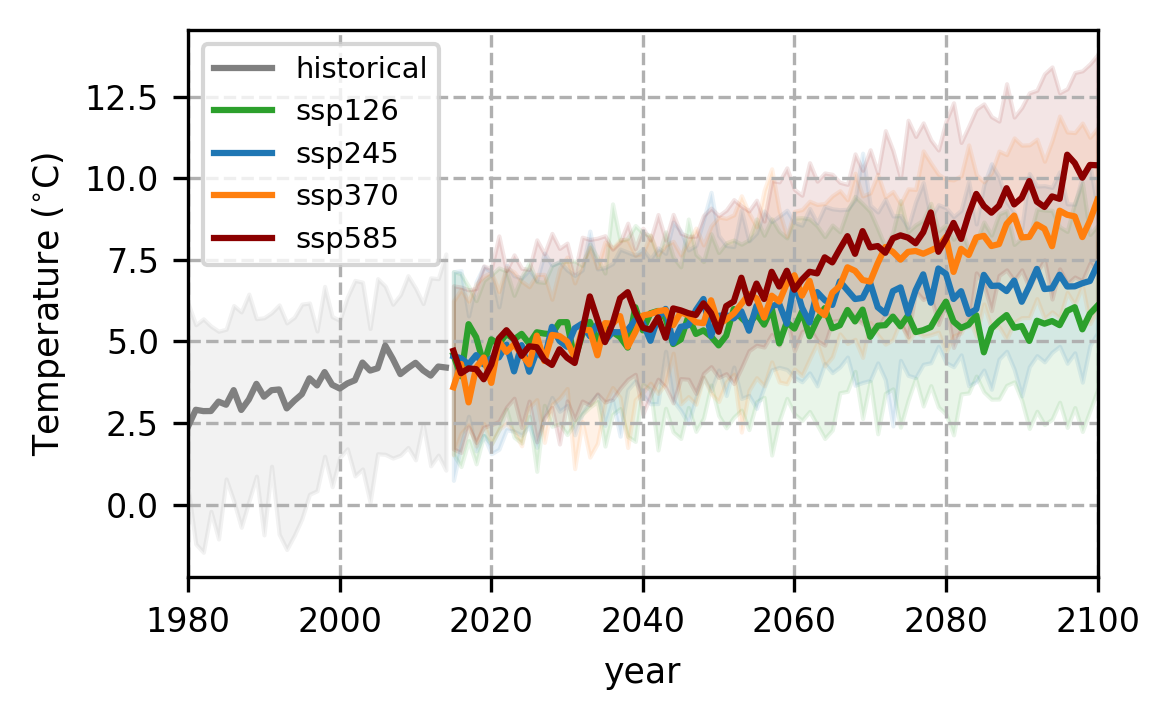

In [241]:
experiments= ['historical', 'ssp126','ssp245','ssp370','ssp585']

fig, ax = plt.subplots(1, 1, figsize = (4, 2.5),dpi=300)

colours = ['grey','tab:green','tab:blue','tab:orange','darkred']
for i in np.arange(len(experiments)):
    ax.plot(cmip6_ens_ds_yr.tasmax_50.year, cmip6_ens_ds_yr.tasmax_50[i,:], color=f'{colours[i]}', 
            label=f'{cmip6_ens_ds_yr.tasmax_50.experiment[i].values}')
    
    ax.fill_between(cmip6_ens_ds_yr.tasmax_50.year, cmip6_ens_ds_yr.tasmax_95[i,:], cmip6_ens_ds_yr.tasmax_05[i, :], alpha=0.1, color=f'{colours[i]}') 
            #label=f'{cmip6_ens18.tas_50.experiment[i].values} 10th and 90th quantile range')

#cm_obs_oul_agg_yr.tas.plot(label='OBSERVED',linewidth=2, color='orange')
ax.set_xlim(1980,2100)
#ax.set_title('CMIP6 annual temperature', fontsize= 10)
ax.set_ylabel('Temperature ($^{\circ}$C)',fontsize= 'small')
ax.xaxis.set_tick_params(labelsize=8)
ax.yaxis.set_tick_params(labelsize=8)
ax.set_xlabel('year',fontsize= 'small')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels,fontsize= 'x-small')
ax.grid(linestyle='--')
plt.tight_layout()

fig.savefig(f'CMIP6_projection_tasmax.png')

# Seasonal changes

In [16]:
def ensemble_mean(cm):
    cmip6= cm['tas_50']
    cmip6_tas = cmip6.to_dataset(name='tas')
    # creating attributes
    cmip6_tas['tas'].attrs['units'] ='degrees celcius'
    cmip6_tas['lat'].attrs['units'] ='degrees north '
    cmip6_tas['lon'].attrs['units'] ='degrees east'
    
    return cmip6_tas

def ens_period(cm, start, end):
    cm_period= cm.tas[1:5].sel(time= slice(start, end))
    return cm_period

def groupby_day(cm):
    cm_day= cm.groupby('time.dayofyear').mean('time',skipna=False)
    return cm_day

def groupby_season(cm):
    cm_season_mean= cm.groupby('time.season').mean('time',skipna=False)
    return cm_season_mean

def groupby_month(cm):
    cm_season_mean= cm.groupby('time.month').mean('time',skipna=False)
    return cm_season_mean

def groupby_year(cm):
    cm_yr= cm.groupby('time.year').mean('time',skipna=False)
    return cm_yr

def anomly(cm, cm_his):
    cm_delta=  (cm-cm_his)
    cm_delta.attrs['units'] ='degrees celcius'

    return cm_delta 

def anomly_day(cm, cm_his):
    cm_change=  (cm-cm_his)
    cm_change.attrs['units'] ='Degrees Celcius'

    return cm_change 

# Extracting scenarios from files

In [70]:
hist = DTR_cm.DTR[0]
ssp126= DTR_cm.DTR[1]
ssp245= DTR_cm.DTR[2]
ssp370= DTR_cm.DTR[3]
ssp585= DTR_cm.DTR[4]


#converting dataarrays to dataset
hist_ds= hist.to_dataset(name='DTR')
hist_ds.attrs['experiment_id']= 'historical'
hist_ds.attrs['variable_id']= 'DTR'
hist_ds.attrs['source_id']= 'cmip6_ens'



hist_ds['DTR'].attrs['units'] ='degrees celcius'
hist_ds['lat'].attrs['units'] ='degrees north '
hist_ds['lon'].attrs['units'] ='degrees east'


ssp126_ds= ssp126.to_dataset(name='DTR')
ssp126_ds.attrs['experiment_id']= 'ssp126'
ssp126_ds.attrs['variable_id']= 'DTR'
ssp126_ds.attrs['source_id']= 'cmip6_ens'

ssp126_ds['DTR'].attrs['units'] ='degrees celcius'
ssp126_ds['lat'].attrs['units'] ='degrees north '
ssp126_ds['lon'].attrs['units'] ='degrees east'



ssp245_ds= ssp245.to_dataset(name='DTR')
ssp245_ds.attrs['experiment_id']= 'ssp245'
ssp245_ds.attrs['variable_id']= 'DTR'
ssp245_ds.attrs['source_id']= 'cmip6_ens'

ssp245_ds['DTR'].attrs['units'] ='degrees celcius'
ssp245_ds['lat'].attrs['units'] ='degrees north '
ssp245_ds['lon'].attrs['units'] ='degrees east'


ssp370_ds= ssp370.to_dataset(name='DTR')
ssp370_ds.attrs['experiment_id']= 'ssp370'
ssp370_ds.attrs['variable_id']= 'DTR'
ssp370_ds.attrs['source_id']= 'cmip6_ens'

ssp370_ds['DTR'].attrs['units'] ='degrees celcius'
ssp370_ds['lat'].attrs['units'] ='degrees north '
ssp370_ds['lon'].attrs['units'] ='degrees east'


ssp585_ds= ssp585.to_dataset(name='DTR')
ssp585_ds.attrs['experiment_id']= 'ssp585'
ssp585_ds.attrs['variable_id']= 'DTR'
ssp585_ds.attrs['source_id']= 'cmip6_ens'

ssp585_ds['DTR'].attrs['units'] ='degrees celcius'
ssp585_ds['lat'].attrs['units'] ='degrees north '
ssp585_ds['lon'].attrs['units'] ='degrees east'


In [73]:
#Exporting to netcdf
hist_ds.to_netcdf(r"D:\Ensemble_Finland\Finland\Cmip6_ens\hist_DTR.nc")

ssp126_ds.to_netcdf(r"D:\Ensemble_Finland\Finland\Cmip6_ens\ssp126_DTR.nc")
ssp245_ds.to_netcdf(r"D:\Ensemble_Finland\Finland\Cmip6_ens\ssp245_DTR.nc")
ssp370_ds.to_netcdf(r"D:\Ensemble_Finland\Finland\Cmip6_ens\ssp370_DTR.nc")
ssp585_ds.to_netcdf(r"D:\Ensemble_Finland\Finland\Cmip6_ens\ssp585_DTR.nc")

# Bias correcting ensemble

In [74]:

DATADIR7= r"D:\Ensemble_Finland\Finland\Cmip6_ens\Ens DTR\ssp*DTR.nc"
path7= glob(f'{DATADIR7}')

DATADIR8= r"D:\Ensemble_Finland\Finland\Cmip6_ens\Ens DTR\hist*DTR.nc"
path8= glob(f'{DATADIR8}')

In [84]:
#Directory to bias corrected scenarios

DATADIR9= r"D:\Ensemble_Finland\Finland\Bias corrected\DTR/"
path9 =glob(f'{DATADIR9}DTR*ssp*.nc')

### Bias correcting DTR

In [ ]:
for file in path8:
    cm_hist= xr.open_dataset(file)
    #Getting attibutes
    exp= cm_hist.attrs['experiment_id']
    var= cm_hist.attrs['variable_id']
    mod = cm_hist.attrs['source_id']
        
    cm_hist2 = cm_hist.sel(time=slice(None, '2014-12-31'))

    #Regridding data to 1x1 grid
    cm_hist_ds= coarse_fine(cm_hist2, cm_obs_min)
    
    
    #Clipping to finland
    cm_hist_fin = clip_fin(cm_hist_ds, shp_fin)
    
    cm_hist_fin['DTR'].attrs['units'] ='degC'

    #Changing calendars
    cm_hist_fin= calendar(cm_hist_fin)

   
    print('worked on historical file')

for file in path7:

    cm_raw= xr.open_dataset(file)
    
    try:

        #Getting attibutes
        exp= cm_raw.attrs['experiment_id']
        var= cm_raw.attrs['variable_id']
        mod = cm_raw.attrs['source_id']
        
        cm_raw = cm_raw.sel(time=slice('2015-01-01', None))
        cm_raw_ds= coarse_fine(cm_raw, cm_obs_min)
        
        #Clipping to finland
        cm_raw_fin = clip_fin(cm_raw_ds, shp_fin)
        
        cm_raw_fin['DTR'].attrs['units'] ='degC'
        
        #Changing calendars
        cm_obs_fin= calendar(cm_obs_fin)
                
        cm_raw_fin= calendar(cm_raw_fin)
        

        #bias correction
        cm_bc= tas_detrended_qdm(cm_obs_fin, cm_hist_fin, cm_raw_fin)
        
        
        #Changing calendar back
        cm_bc= change_calendar(cm_bc)
        
        
        #Exporting file
        cm_bc.to_netcdf(f'{DATADIR9}{var}_{mod}_{exp}.nc')
        print(f'{var}_{mod}_{exp} has been exported')

      
    except Exception as err:
        print(err)

In [ ]:
#Bias correcting the historical file

exp_h= cm_hist_fin.attrs['experiment_id']
var_h= cm_hist_fin.attrs['variable_id']
mod_h = cm_hist_fin.attrs['source_id']

#bias correction
cm_bc_hist= tas_detrended_qdm(cm_obs_fin, cm_hist_fin, cm_hist_fin)

 #Changing calendar back
cm_bc_hist= change_calendar(cm_bc_hist)

#Exporting file
cm_bc_hist.to_netcdf(f'{DATADIR9}{var_h}_{mod_h}_{exp_h}.nc')


In [18]:
DATADIR11= r"D:\Ensemble_Finland\Finland\Bias corrected/"
path11 =glob(f'{DATADIR11}*ssp*.nc')

In [ ]:
for file in path11:
    cm=xr.open_dataset(file)
    
    cm.attrs['variable_id']= 'tasmax'
    
    exp= cm.attrs['experiment_id']
    var= cm.attrs['variable_id']
    mod = cm.attrs['source_id']
    
    
    cm.to_netcdf(f'{DATADIR11}{var}_{mod}_{exp}.nc')
    print(f'{var}_{mod}_{exp} has been exported')

# Bias corrected Tmin from DTR

In [91]:
DATADIR10= r"D:\Ensemble_Finland\Finland\Bias corrected\DTR/"
path10 =glob(f'{DATADIR10}DTR*ssp5*.nc')

In [92]:

DATADIR12= r"D:\Ensemble_Finland\Finland\Bias corrected\Tasmax/"
path12 =glob(f'{DATADIR12}tasmax*ssp5*.nc')

In [100]:
#Directory to store the files
DATADIR13=r"D:\Ensemble_Finland\Finland\Bias corrected\Tasmin/"

In [95]:
def tasmin(ds_max, ds_dtr):
    dr_dtr= ds_max.tasmax-ds_dtr.DTR
    
    dr_dtr.attrs['units'] ='degC'
    dr_dtr.attrs['long_name'] ='Daily minimum temperature'
    
    dr_dtr.attrs['bias_adjustment']='Detrended Quantile delta Mapping (DTR and Tasmax)'
    
    ds_dtr= dr_dtr.to_dataset(name='tasmin')
    ds_dtr.attrs['variable_id']= 'tasmin'
    
    ds_dtr.attrs['experiment_id']= exp
    ds_dtr.attrs['source_id']= mod
    
    
    
    return ds_dtr

In [ ]:
for file in path10:
    cm_dtr= xr.open_dataset(file)
    
    
for file in path12:
    cm_max= xr.open_dataset(file)
    exp= cm_max.attrs['experiment_id']
   
    mod = cm_max.attrs['source_id']
   

    cm_tasmin=tasmin(cm_max, cm_dtr)

    var='tasmin'

    cm_tasmin.to_netcdf(f'{DATADIR13}{var}_{mod}_{exp}.nc')
    print(f'{var}_{mod}_{exp} has been exported')

### Performace of Ensemble

In [ ]:
#raw ensemble 
cm_hist_raw = xr.open_dataset(r"D:\Ensemble_Finland\cmip6_model_ens_tasmin2.nc")
cm_hist_raw= cm_hist_raw.rename({'tasmin_50': 'tasmin'})
cm_hist_raw= cm_hist_raw.sel(time= slice(None, '2014-12-31'))

cm_hist_ds= coarse_fine(cm_hist_raw, cm_obs_min)


In [24]:
cm_hist_bc = xr.open_dataset(r"D:\Ensemble_Finland\Finland\Bias corrected\Tasmin\tasmin_cmip6_ens_historical.nc")


In [26]:
cm_obs2014 = cm_obs_min.sel(time=slice(None, '2014-12-31'))
cm_obs2014m = cm_obs2014.resample(time='M').mean(dim='time', skipna=False)

sd_obsm= cm_obs2014m.std(skipna= True)
sdm= np.nanmean(sd_obsm.tasmin)
print(sdm)

In [ ]:
cm_hist_m =cm_hist_ds.resample(time='M').mean(dim='time', skipna=False)

cm_hist_bc_m =cm_hist_bc.resample(time='M').mean(dim='time', skipna=False)
        

#Evalution of methods
#Person Correlation
print(f'The cofficient of correlation before  bias correcction of ENS is {pearson_correlation(cm_obs2014m,cm_hist_m )}')

print(f'The cofficient of correlation after  bias correcction of ENS is {pearson_correlation(cm_obs2014m,cm_hist_bc_m )}')


#Absolute mean error.
print(f'The mean Absolute error before  bias correcction of model ENS is {mean_absolute_error(cm_obs2014m, cm_hist_m)}')

print(f'The mean Absolute error after  bias correcction of model ENS is {mean_absolute_error(cm_obs2014m, cm_hist_bc_m)}')

# Standard deviation

print(f'The Standard devaiation before bias correcction of model ENS is {standard_deviation(cm_hist_m)}')
print(f'The Standard devaiation after bias correcction of model ENS is {standard_deviation(cm_hist_bc_m)}')
  
#Root mean square error
print(f'The root_mean_square_error before bias correcction of model ENS is {root_mean_square_error(cm_obs2014m,cm_hist_m )}')
print(f'The root_mean_square_error after bias correcction of model ENS is {root_mean_square_error(cm_obs2014m, cm_hist_bc_m)}')



In [ ]:
#Model performance

In [30]:
DATADIR9= r"D:\GCM\**\Bias corrected sdbc\Oul/"
path9= glob(f'{DATADIR9}*tasmin*historical.nc')

In [ ]:
for file in path9:
    cm_bc= xr.open_dataset(file)
    
    try:

        #Getting attibutes
        exp= cm_bc.attrs['experiment_id']
        mod = cm_bc.attrs['source_id']        
               
        
        cm_oul_bc_m = cm_bc.resample(time='M').mean(dim='time', skipna=False)

        #Evalution of methods
         #Person Correlation
        print(f'The coefficient of correlation before  bias correcction of model {mod} is {pearson_correlation(cm_obs2014m, cm_hist_bc_m)}')
               
     
        #Absolute mean error.
        
        print(f'The mean Absolute error before  bias correcction of model {mod} is {mean_absolute_error(cm_obs2014m, cm_hist_bc_m)}')
        
        # Standard deviation
        print(f'The Standard devaiation before bias correcction of model {mod} is {standard_deviation(cm_hist_bc_m)}')
        
        print(f'The root_mean_square_error before bias correcction of model {mod} is {root_mean_square_error(cm_obs2014m, cm_hist_bc_m)}')

        
       
    except Exception as err:
        print(err)
    

## References 

<font size ='3.2'>Agbazo, M.N., Grenier, P., 2020. Characterizing and avoiding physical inconsistency generated by the application of univariate quantile mapping on daily minimum
and maximum temperatures over Hudson Bay. Int. J. Climatol. 40, 3868–3884. https://doi.org/10.1002/joc.6432.</font>

<font size ='3.2'>Bell, R., Spring, A., Brady, R., Huang, A., Squire, D., Blackwood, Z., Sitter, M., Chegini, T., 2021. xarray-contrib/xskillscore: Release v0.0.23 [WWW Document].
https://doi.org/10.5281/zenodo.5173153.</font>

<font size ='3.2'>Bourgault, P., Huard, D., Smith, T.J., Aoun, A., Lavoie, J., Dupuis, E., ´ Alegre, R., Barnes, C., Beaupr´e, A., Biner, S., Caron, D., Ehbrecht, C., Keel, T., Labont´e, M.,
Lierhammer, L., Low, J., Quinn, J., Roy, P., Squire, D., 2023. xclim: xarray-based climate data analytics. J. Open Source Softw. 8, 8–11. https://doi.org/
10.21105/joss.05415.</font>

<font size ='3.2'>Zhuang, J., Dussin, R., Huard, D., Bourgault, P., Banihirwe, A., Raynaud, S., Malevich, B., Schupfner, M., Filipe, Levang, S., Gauthier, C., Jüling, A., Almansi, M.,
RichardScott O.Z., Rondeau G., Rasp, S., Smith, T.J., Stachelek, J., Plough, M., Pierre, Bell, R., Caneill, R., Li, X., 2023. pangeo-data/xESMF: v0.8.2 [WWW
Document]. zenodo.org. https://doi.org/10.5281/zenodo.4294774.</font>
        
